In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#CHART STYLE
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.4)


In [2]:
#LOADING DATA

data_dir = 'processed_data/'

X = pd.read_csv(f"{data_dir}X_train_selected_100.csv", index_col=0)
y = pd.read_csv(f"{data_dir}y_train.csv", index_col=0)

df = X.copy()
df['Diagnoza'] = y
df['Diagnoza'] = df['Diagnoza'].map({0: 'Healthy', 1: 'Cancer (KIRC)'})


In [3]:
gene_map = {
    'ENSG00000167580.8': 'AQP2',
    'ENSG00000074803.20': 'SLC12A1',
    'ENSG00000170561.13': 'IRX2',
    'ENSG00000173253.15': 'DMRT2',
    'ENSG00000105929.16': 'ATP6V0A4'
}

top_genes_ids = list(gene_map.keys())


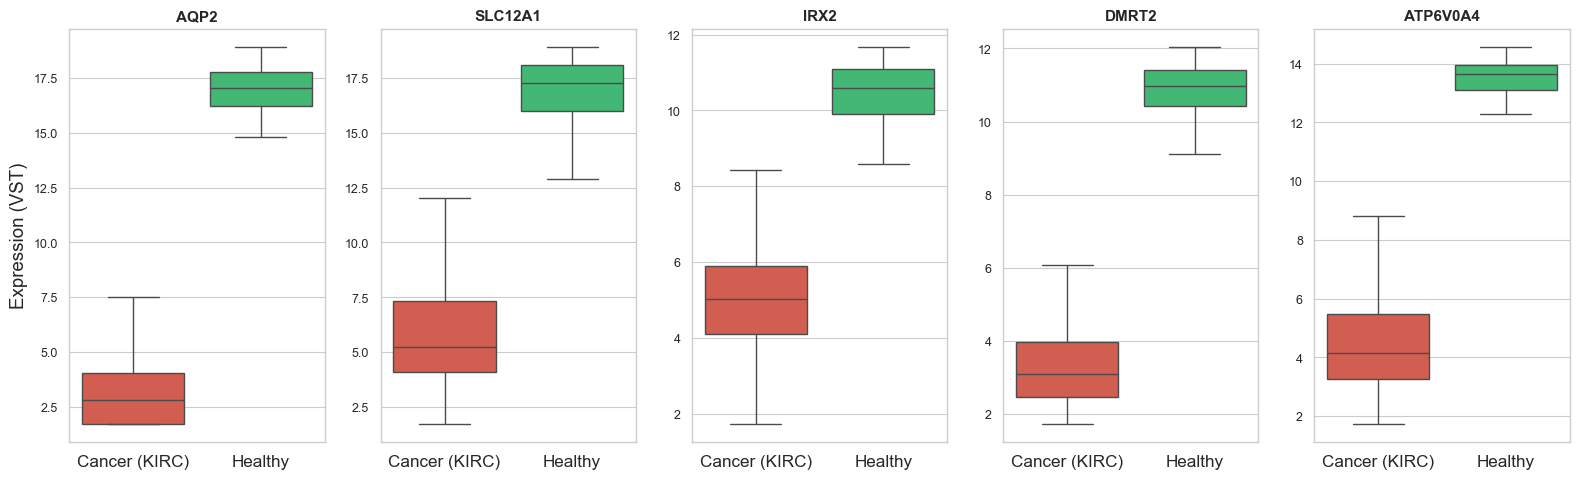

In [8]:
#DRAWING

plt.figure(figsize=(16, 5))

for i, gene_id in enumerate(top_genes_ids, 1):
    if gene_id not in df.columns:
        found = [c for c in df.columns if gene_id.split('.')[0] in c]
        if found:
            gene_id = found[0]
        else:
            print(f"Pominięto {gene_id} - brak w danych")
            continue

    plt.subplot(1, 5, i)

    gene_name = gene_map.get(gene_id, gene_id)

    sns.boxplot(
        data=df,
        x='Diagnoza',
        y=gene_id,
        hue='Diagnoza',
        palette=['#e74c3c', '#2ecc71'],
        legend=False,
        showfliers=False
    )

    plt.title(gene_name, fontsize=11, fontweight='bold')
    plt.ylabel('Expression (VST)' if i==1 else '')
    plt.xlabel('')
    plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('Biological_Charts_Final.png', dpi=300)
plt.show()
